# Choosing Colormaps in Matplotlib

📄 Source: https://matplotlib.org/stable/users/explain/colors/colormaps.html

Matplotlib has many built-in colormaps (`matplotlib.colormaps`). This page explains how to choose between them, and why rainbow maps like `jet` are a bad default.

> **Needs one extra package** (used by the docs to measure lightness): `pip install colorspacious`

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from colorspacious import cspace_converter   # converts RGB to a perceptual colour space

print("matplotlib", mpl.__version__)

matplotlib 3.11.2


In [2]:
# All registered colormaps:
from matplotlib import colormaps
print(len(list(colormaps)), "colormaps, e.g.", list(colormaps)[:8])

182 colormaps, e.g. ['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo']


## Overview

The best colormap depends on:
- whether you show **form** or **metric** data,
- your knowledge of the data (is there a critical middle value?),
- whether there is an intuitive colour scheme for the variable,
- what your field/audience expects.

For many uses a **perceptually uniform** colormap is best: equal steps in data look like equal steps in colour. People read changes in **lightness** much better than changes in hue, so colormaps whose lightness increases monotonically are easier to read.

Colour can be described in CIELAB space: **L\*** = lightness, a\* = red-green, b\* = yellow-blue. The L\* value tells us how a colormap will be perceived.

## Classes of colormaps

1. **Sequential**: lightness (and often saturation) changes step by step, often in one hue. Use for **ordered** data (amounts).
2. **Diverging**: two colours that meet at an unsaturated colour in the middle. Use when there is a **critical middle value** (zero, an average), e.g. correlations.
3. **Cyclic**: two colours meeting in the middle and at the ends. Use for values that **wrap around** (angle, wind direction, time of day).
4. **Qualitative**: miscellaneous colours. Use for **categories** with no order.

First, show the range of each colormap. Some seem to change more "quickly" than others.

In [3]:
cmaps = {}   # we save each category's list here to reuse later

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))   # a 2-row image going from 0 to 1


def plot_color_gradients(category, cmap_list):
    """Draw one horizontal colour strip per colormap name."""
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)   # name to the left of the strip

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list

### Sequential

Lightness increases monotonically. Good. Some span L\* from 0 to 100 (the greys), others start around 20, so they have a smaller perceptual range. Some are close to linear in L\*, others are curved.

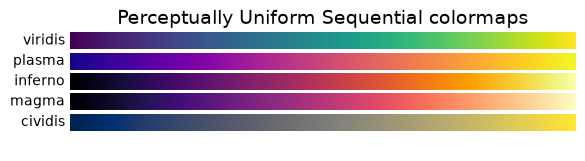

In [4]:
plot_color_gradients('Perceptually Uniform Sequential',
                     ['viridis', 'plasma', 'inferno', 'magma', 'cividis'])

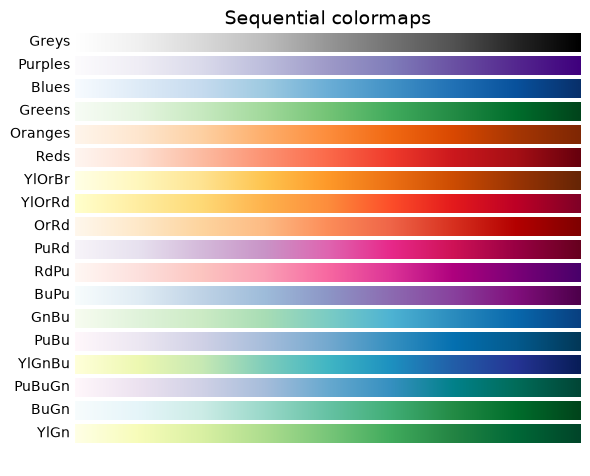

In [5]:
plot_color_gradients('Sequential',
                     ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn'])

### Sequential2

Many are monotonic, but some (autumn, cool, spring, winter) plateau or go up and down in L\*. Others (afmhot, copper, gist_heat, hot) have kinks. Data in a plateau or kink region looks like **bands** that aren't really there.

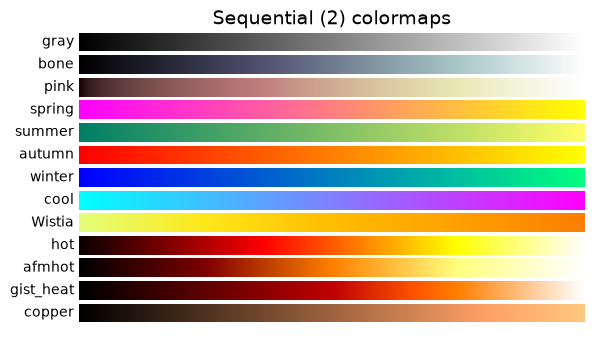

In [6]:
plot_color_gradients('Sequential (2)',
                     ['gray', 'bone', 'pink', 'spring', 'summer', 'autumn',
                      'winter', 'cool', 'Wistia', 'hot', 'afmhot', 'gist_heat',
                      'copper'])

*Discouraged names* (kept for backward compatibility): `gist_gray` → use `gray`; `gist_yarg` and `binary` → use `gray_r`.

### Diverging

L\* should rise to a maximum near 100 in the middle, then fall, with similar minimum L\* at both ends. **BrBG** and **RdBu** are good choices. `coolwarm` is OK but has a small L\* range. `berlin`, `managua`, `vanimo` are dark-mode diverging maps (darkest in the middle).

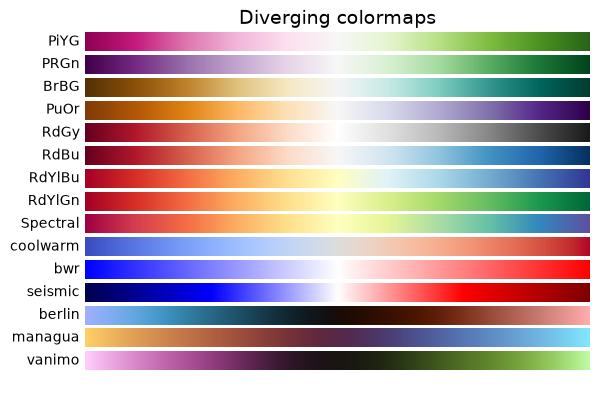

In [7]:
plot_color_gradients('Diverging',
                     ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
                      'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic',
                      'berlin', 'managua', 'vanimo'])

### Cyclic

Start and end on the same colour, symmetric around the middle. `hsv` is in this group but is **not** symmetric and its L\* varies a lot, so it's a poor choice for data.

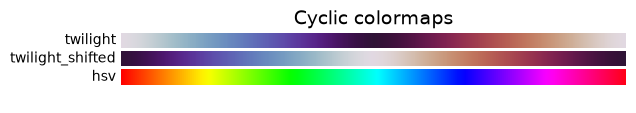

In [8]:
plot_color_gradients('Cyclic', ['twilight', 'twilight_shifted', 'hsv'])

### Qualitative

Not meant to be perceptual: L\* jumps around. Fine for categories, bad for numbers. (`okabe_ito` is a colour-blind-friendly qualitative set.)

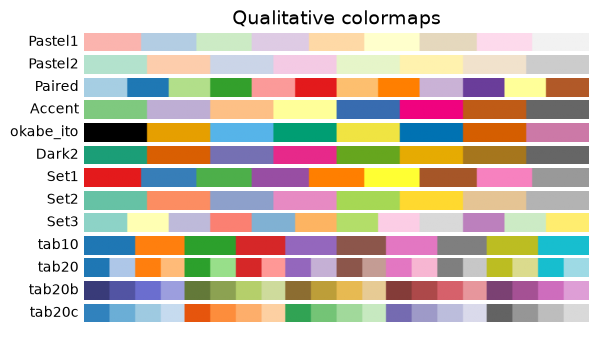

In [9]:
plot_color_gradients('Qualitative',
                     ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'okabe_ito',
                      'Dark2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20',
                      'tab20b', 'tab20c'])

### Miscellaneous

Special-purpose maps (gist_earth, ocean, terrain for topography; CMRmap converts well to greyscale; cubehelix varies smoothly in lightness and hue; turbo for depth data).
The often-used **`jet`** is here: its L\* varies widely, so it is a **poor choice** for showing data.

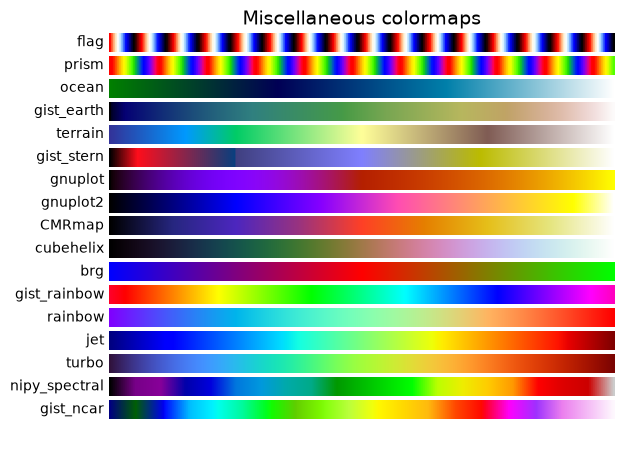

In [10]:
plot_color_gradients('Miscellaneous',
                     ['flag', 'prism', 'ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet',
                      'turbo', 'nipy_spectral', 'gist_ncar'])

plt.show()

## Lightness of Matplotlib colormaps

Now plot the L\* (lightness) value along each colormap. **A good map for numbers has a smooth, monotonic L\* line.** Watch `jet` in the last plot: its lightness goes up and down, which creates fake boundaries in your data.

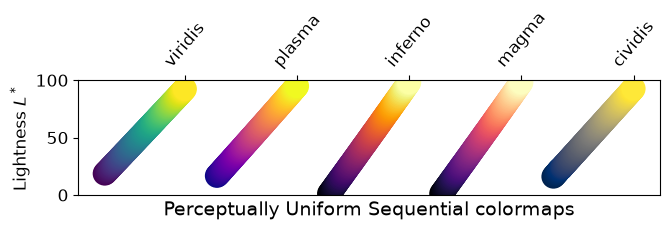

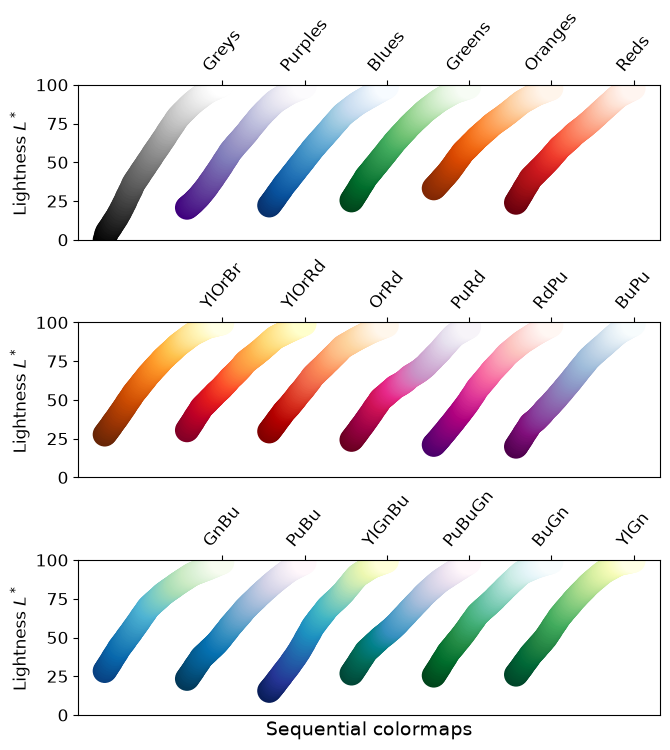

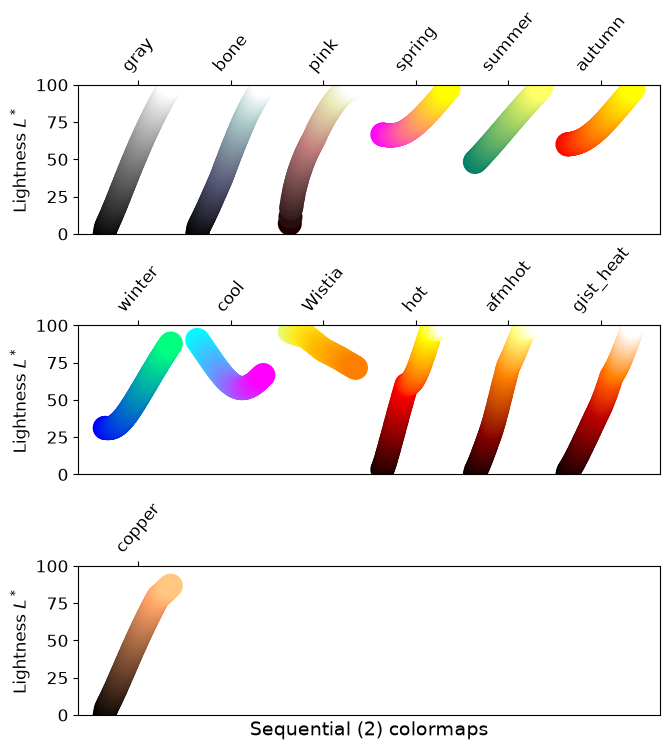

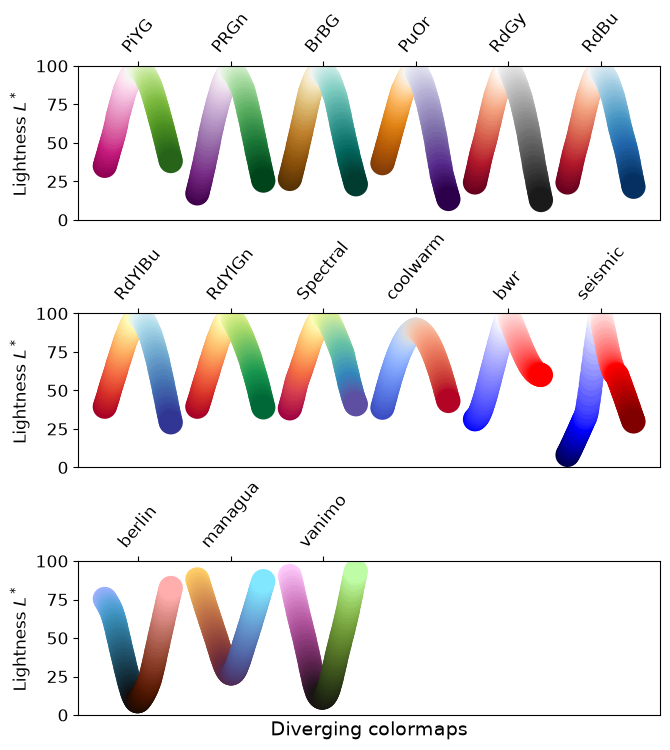

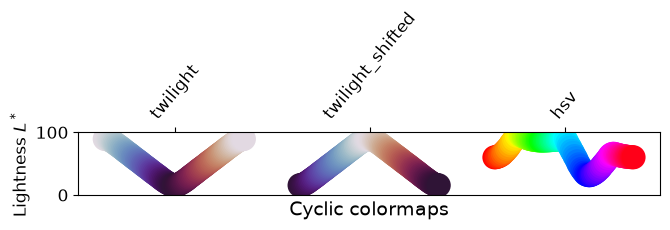

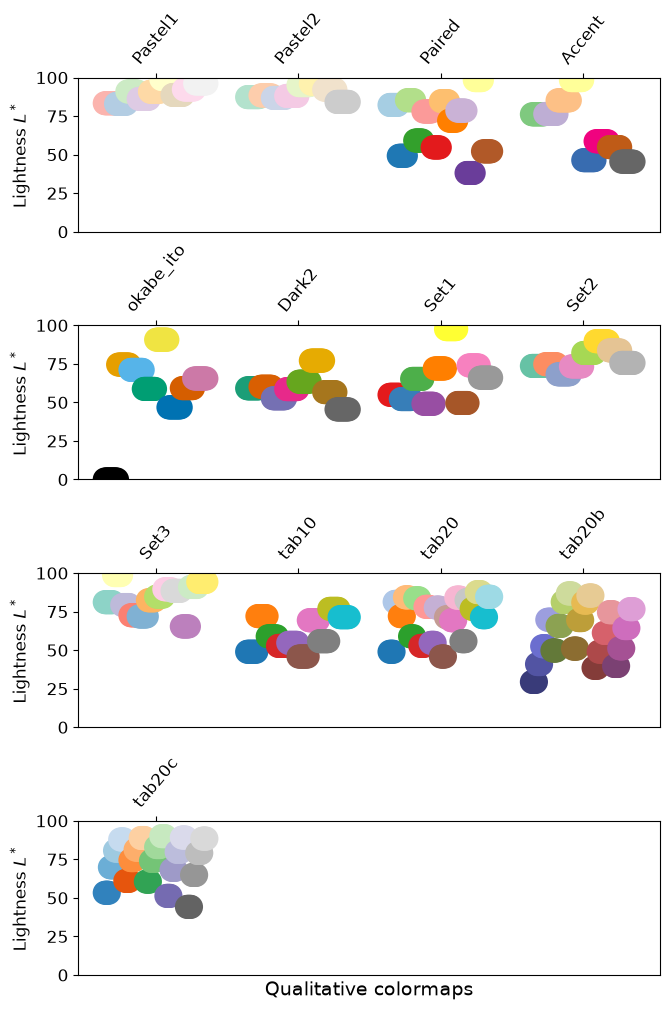

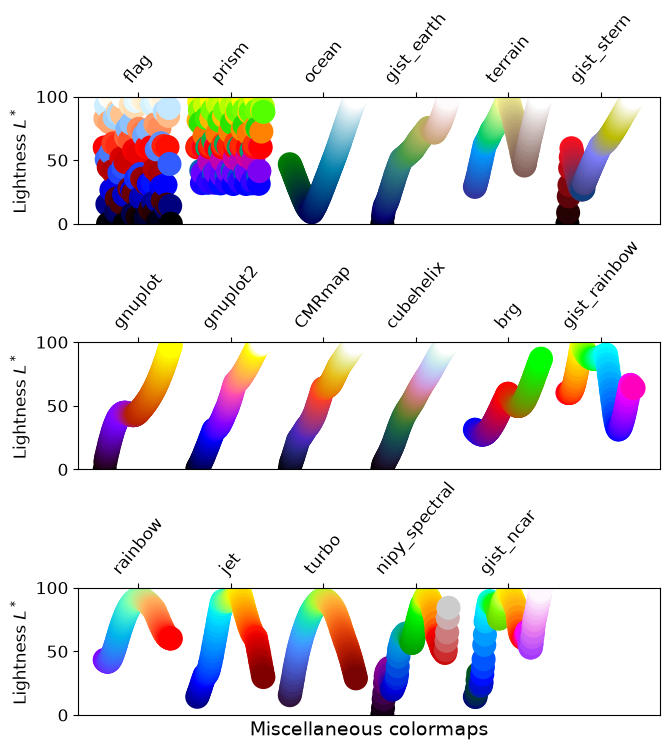

In [11]:
mpl.rcParams.update({'font.size': 12})

# Number of colormap per subplot for particular cmap categories
_DSUBS = {'Perceptually Uniform Sequential': 5, 'Sequential': 6,
          'Sequential (2)': 6, 'Diverging': 6, 'Cyclic': 3,
          'Qualitative': 4, 'Miscellaneous': 6}

# Spacing between the colormaps of a subplot
_DC = {'Perceptually Uniform Sequential': 1.4, 'Sequential': 0.7,
       'Sequential (2)': 1.4, 'Diverging': 1.4, 'Cyclic': 1.4,
       'Qualitative': 1.4, 'Miscellaneous': 1.4}

# Indices to step through colormap
x = np.linspace(0.0, 1.0, 100)

# Do plot
for cmap_category, cmap_list in cmaps.items():

    # Do subplots so that colormaps have enough space.
    # Default is 6 colormaps per subplot.
    dsub = _DSUBS.get(cmap_category, 6)
    nsubplots = int(np.ceil(len(cmap_list) / dsub))

    # squeeze=False to handle similarly the case of a single subplot
    fig, axs = plt.subplots(nrows=nsubplots, squeeze=False,
                            figsize=(7, 2.6*nsubplots))

    for i, ax in enumerate(axs.flat):

        locs = []  # locations for text labels

        for j, cmap in enumerate(cmap_list[i*dsub:(i+1)*dsub]):

            # Get RGB values for colormap and convert the colormap in
            # CAM02-UCS colorspace.  lab[0, :, 0] is the lightness.
            rgb = mpl.colormaps[cmap](x)[np.newaxis, :, :3]
            lab = cspace_converter("sRGB1", "CAM02-UCS")(rgb)

            # Plot colormap L values.  Do separately for each category
            # so each plot can be pretty.
            if cmap_category == 'Sequential':
                # These colormaps all start at high lightness, but we want them
                # reversed to look nice in the plot, so reverse the order.
                y_ = lab[0, ::-1, 0]
                c_ = x[::-1]
            else:
                y_ = lab[0, :, 0]
                c_ = x

            dc = _DC.get(cmap_category, 1.4)  # cmaps horizontal spacing
            ax.scatter(x + j*dc, y_, c=c_, cmap=cmap, s=300, linewidths=0.0)

            # Store locations for colormap labels
            if cmap_category in ('Perceptually Uniform Sequential',
                                 'Sequential'):
                locs.append(x[-1] + j*dc)
            elif cmap_category in ('Diverging', 'Qualitative', 'Cyclic',
                                   'Miscellaneous', 'Sequential (2)'):
                locs.append(x[int(x.size/2.)] + j*dc)

        # Set up the axis limits:
        #   * the 1st subplot is used as a reference for the x-axis limits
        #   * lightness values goes from 0 to 100 (y-axis limits)
        ax.set_xlim(axs[0, 0].get_xlim())
        ax.set_ylim(0.0, 100.0)

        # Set up labels for colormaps
        ax.xaxis.set_ticks_position('top')
        ticker = mpl.ticker.FixedLocator(locs)
        ax.xaxis.set_major_locator(ticker)
        formatter = mpl.ticker.FixedFormatter(cmap_list[i*dsub:(i+1)*dsub])
        ax.xaxis.set_major_formatter(formatter)
        ax.xaxis.set_tick_params(rotation=50)
        ax.set_ylabel('Lightness $L^*$', fontsize=12)

    ax.set_xlabel(cmap_category + ' colormaps', fontsize=14)

    fig.tight_layout(h_pad=0.0, pad=1.5)
    plt.show()

## Grayscale conversion

Charts often get printed in black and white. Colormaps with **monotonic L\*** print sensibly in greyscale; others collapse to the same grey (autumn, spring, summer, winter) or go dark → light → dark (Accent, hsv, **jet**, turbo), which makes the printed chart unreadable.
Left column: the colormap. Right column: its lightness alone (≈ what a greyscale print shows).

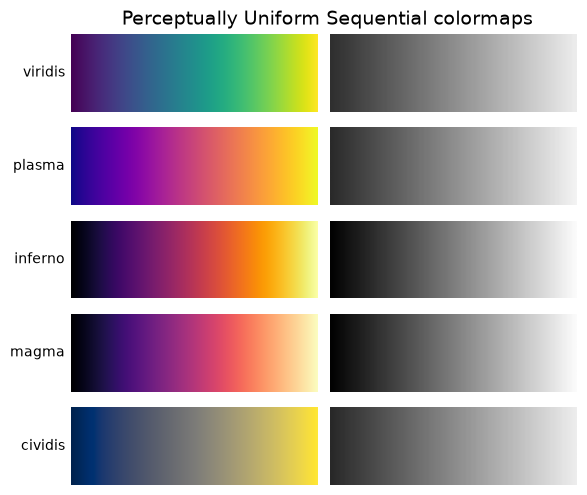

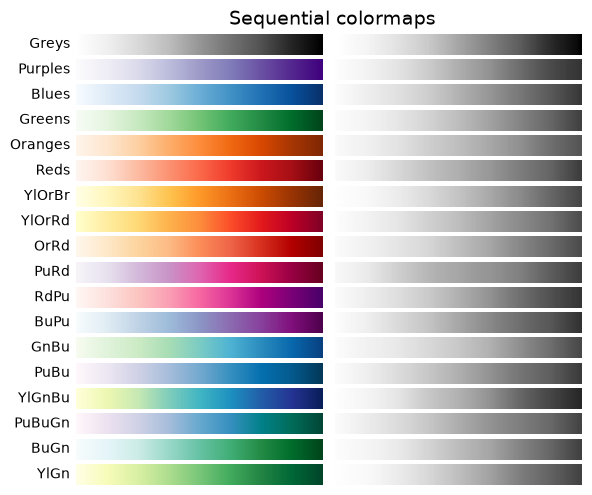

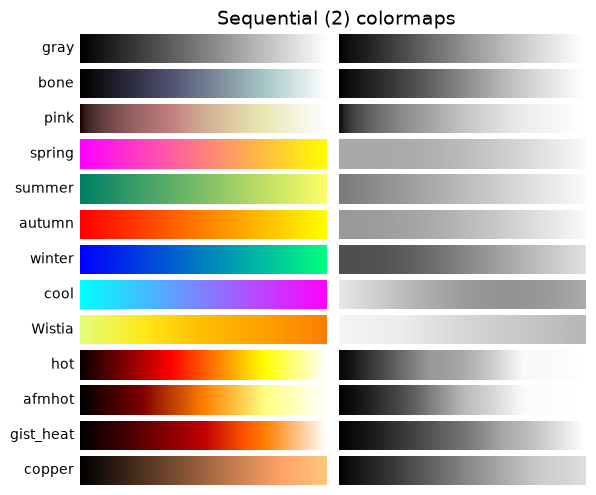

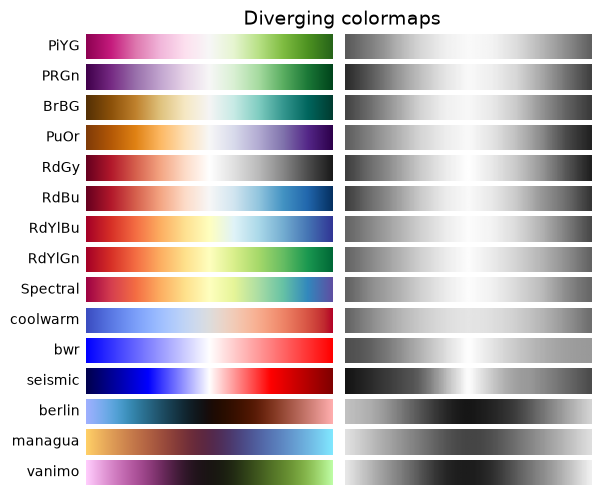

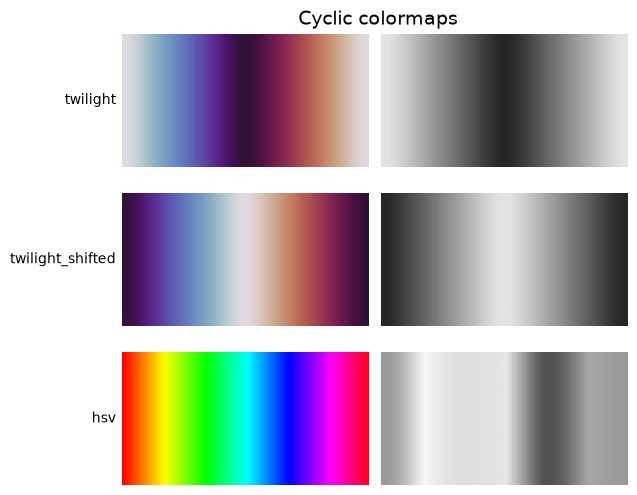

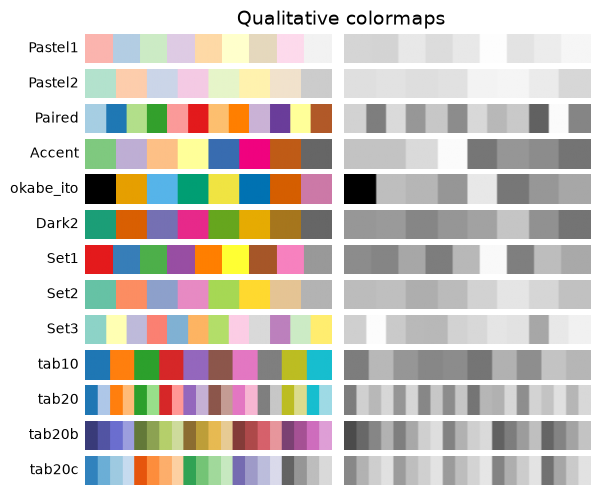

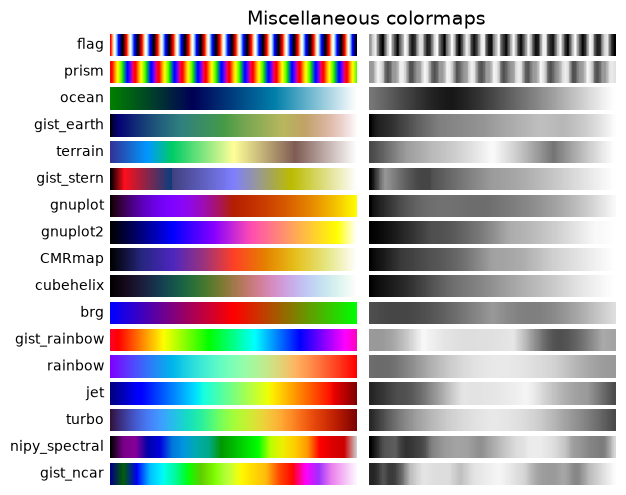

In [12]:
mpl.rcParams.update({'font.size': 14})

# Indices to step through colormap.
x = np.linspace(0.0, 1.0, 100)

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(cmap_category, cmap_list):
    """Colormap on the left, its L* (greyscale) on the right."""
    fig, axs = plt.subplots(nrows=len(cmap_list), ncols=2)
    fig.subplots_adjust(top=0.95, bottom=0.01, left=0.2, right=0.99,
                        wspace=0.05)
    fig.suptitle(cmap_category + ' colormaps', fontsize=14, y=1.0, x=0.6)

    for ax, name in zip(axs, cmap_list):

        # Get RGB values for colormap.
        rgb = mpl.colormaps[name](x)[np.newaxis, :, :3]

        # Get colormap in CAM02-UCS colorspace. We want the lightness.
        lab = cspace_converter("sRGB1", "CAM02-UCS")(rgb)
        L = lab[0, :, 0]
        L = np.float32(np.vstack((L, L, L)))

        ax[0].imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax[1].imshow(L, aspect='auto', cmap='binary_r', vmin=0., vmax=100.)
        pos = list(ax[0].get_position().bounds)
        x_text = pos[0] - 0.01
        y_text = pos[1] + pos[3]/2.
        fig.text(x_text, y_text, name, va='center', ha='right', fontsize=10)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs.flat:
        ax.set_axis_off()

    plt.show()


for cmap_category, cmap_list in cmaps.items():

    plot_color_gradients(cmap_category, cmap_list)

## Color vision deficiencies

The most common colour vision deficiency is telling **red from green**. Avoiding colormaps that use both red and green avoids many problems.

**Demo (my addition):** the same correlation-style data with `jet` vs `RdBu_r` (diverging, centred on 0). `jet` invents bright "edges" around ±0.5; `RdBu_r` shows sign and strength honestly and works for red-green colour blindness.

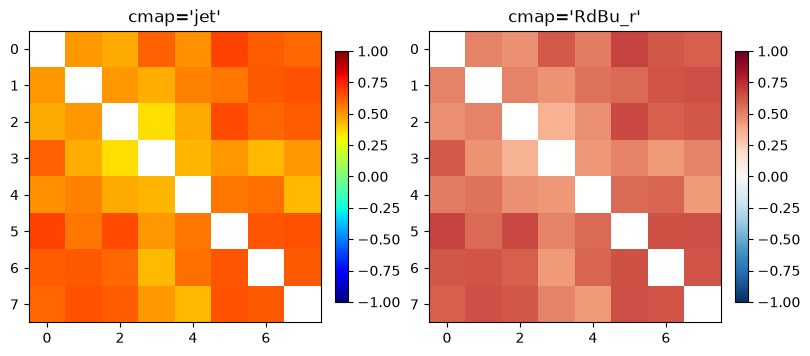

In [13]:
mpl.rcParams.update({'font.size': 10})   # back to the default font size

rng = np.random.default_rng(1)
corr = np.corrcoef(rng.normal(size=(8, 50)) + rng.normal(size=(1, 50)))   # an 8x8 correlation-like matrix
np.fill_diagonal(corr, np.nan)

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), layout="constrained")
for ax, cmap in zip(axs, ["jet", "RdBu_r"]):
    im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)   # fix the range so 0 is the middle colour
    ax.set_title(f"cmap='{cmap}'")
    fig.colorbar(im, ax=ax, shrink=0.8)

## Key takeaways

| Data | Colormap class | Good choices |
| :-- | :-- | :-- |
| amounts, ordered values | Sequential | `viridis`, `cividis`, `Blues` |
| deviation around a midpoint (e.g. correlation) | Diverging | `RdBu_r`, `BrBG` with `vmin=-1, vmax=1` |
| wrap-around values | Cyclic | `twilight` |
| categories | Qualitative | `tab10`, `okabe_ito` |

- Choose maps with **monotonic lightness** for numbers; they also survive greyscale printing.
- **Avoid `jet` / rainbow**: uneven lightness creates fake boundaries.
- Avoid red + green together for colour-blind readers.